# LAB 1 &ndash; Visual cryptography

In order to make sense of some of the things we mentioned in class, it is useful to see them in action on image files; for we, as humans, are quite good at visually detecting patterns in an array of pixels.

First thing to do: double-click on this text cell to write your <b style="color: red">HACKOOLIQUES</b>.

## 1) First attempt

Here is a picture of Bletchley Park, where modern computing was born as Alan Turing and thousands of cryptananalysists worked on the breaking of the German codes during WWII:

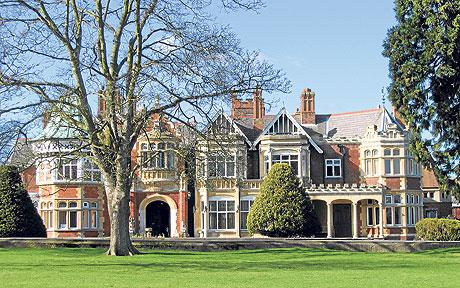

(288, 460) Image

In [2]:
from Image import *              # you may need to pip install matplotlib

m = LoadImage("bletchley.tiff")
m                                # displays it

Internally, it's just a $288 \times 460$ matrix of pixels, each of which is colored according to a RGB triple of integers between 0 and 255:

In [3]:
m.data

array([[[126, 157, 186],
        [200, 231, 255],
        [169, 199, 233],
        ...,
        [ 33,  49,  20],
        [ 83,  98,  59],
        [ 72,  88,  43]],

       [[ 94, 125, 154],
        [145, 176, 207],
        [143, 173, 207],
        ...,
        [128, 143, 114],
        [ 19,  34,   0],
        [140, 155, 112]],

       [[ 28,  59,  90],
        [ 18,  49,  80],
        [ 25,  55,  89],
        ...,
        [ 47,  62,  33],
        [ 70,  84,  48],
        [202, 217, 176]],

       ...,

       [[163, 195,  94],
        [164, 196,  95],
        [170, 202, 101],
        ...,
        [162, 197,  97],
        [162, 197,  97],
        [156, 191,  91]],

       [[168, 200,  99],
        [166, 198,  97],
        [173, 205, 104],
        ...,
        [152, 187,  87],
        [154, 189,  89],
        [152, 187,  87]],

       [[154, 186,  85],
        [152, 184,  83],
        [164, 196,  95],
        ...,
        [161, 196,  96],
        [162, 197,  97],
        [159, 194,  94]]

Recall that the goal of encryption would be to reversibly make it look like a random image of the same size just like this one:

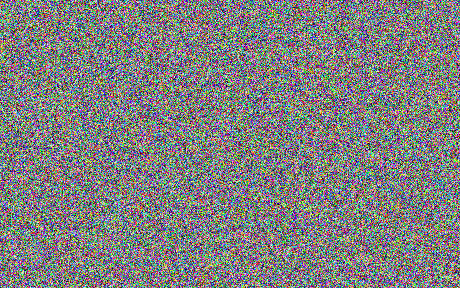

(288, 460) Image

In [4]:
k = RandomImage(288,460)
k

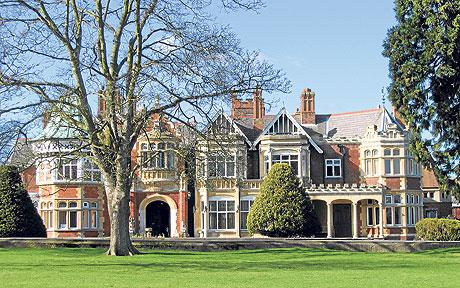

(288, 460) Image

In [13]:
m + k + k

As a single pixel is encoded on $3 \times 8 = 24$ bits, a $4 \times 4$ block of pixels is encoded on $16 \times 24 = 384$ bits, which give us more than enough room to store a secure symmetric encryption key.

In [12]:
k = RandomImage(2,4); k

(2, 4) Image

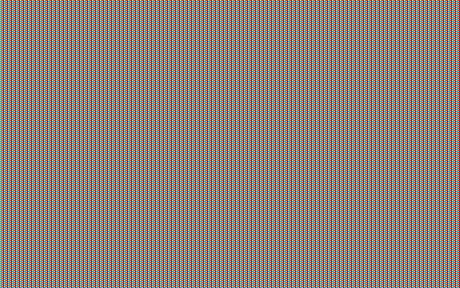

(288, 460) Image

In [13]:
pad = Image(numpy.tile(k.data, (288//2,(230//2),1)))
pad

Et voilà! Here's the picture, encrypted by a 384-bit key:

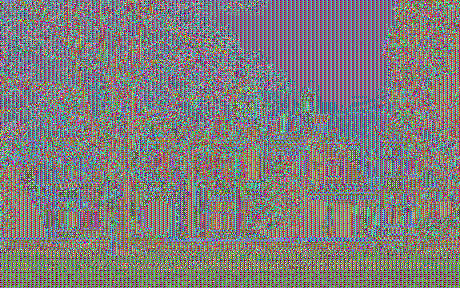

(288, 460) Image

In [14]:
m + pad    # pixel values are xor-ed together

<b>To do:</b> Discuss the result. Would you say that this cipher provides perfect secrecy? 

Avec un masque de 4x4, les zones "uniformes" de l'image sont encore perceptibles dans le chiffré ce qui est très loin d'un secret parfait.
En utilisant un masque plus petit (2x4), les traits de l'image originale apparaîssent encore plus distinctement.

## 2) One-time pad

Go through the same process, this time with a genuine randomly generated one-time pad as large as the image to encrypt.

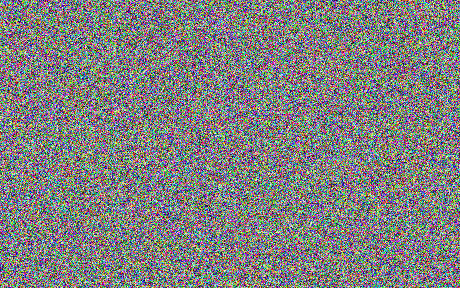

(288, 460) Image

In [15]:
k = RandomImage(288,460)
m + k

What's the key-length this time?

La formule pour obtenir la longueur de la clef correspond à la taille d'un pixel multipliée par le nombre de pixels du masque.
Ici c'est 3x8 comme expliqué plus haut multiplié par la hauteur 288 et la largeur 460 soit: 3179520 bits

In [ ]:
288*460*(3*8) # height * width * pixel_size 

3179520

Verify that the cipher decrypts correctly, <i>i.e.</i> play both the roles of Alice and Bob to see that everything works as it should. Also make sure to take a look at what Eve actually sees on the insecure channel.

Bob dispose du message original.
Il chiffre ensuite son message avec la clef k obtenue ci dessus.
La clef est transmise à Alice par un autre canal.
Le chiffré est ensuite transmis à Alice.
Eve ayant intercepté le message et en absence de la clef, elle ne peut observer le chiffré.
Alice reçoit le message et utilise la clef communiquée en amont pour déchiffrer le chiffré et obtient donc le message.

Bob veut envoyer le message: 

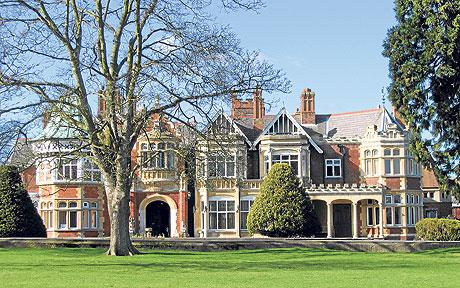

(288, 460) Image
Bob transmet la clef à Alice par un autre canal: 

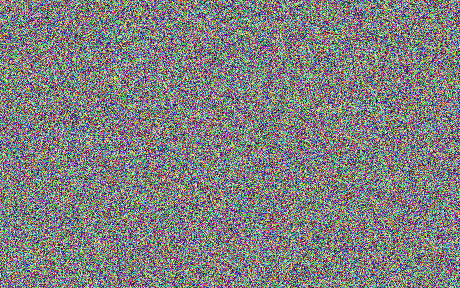

(288, 460) Image
Bob chiffre son message et obtient un chiffré
Eve intercepte le message et sans clef, elle ne peut lire que le chiffré: 

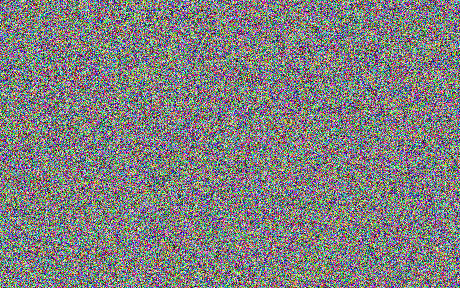

(288, 460) Image
Alice ayant reçu la clef au préalable, elle peut donc déchiffrer le message: 

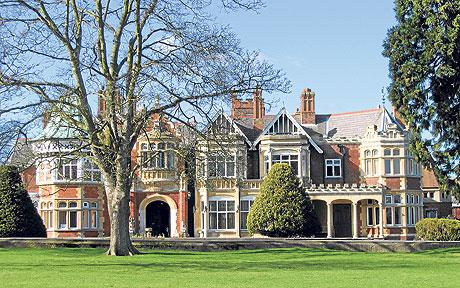

(288, 460) Image


In [24]:
print("Bob veut envoyer le message:",m)
k = RandomImage(288,460)
print("Bob transmet la clef à Alice par un autre canal:", k)
print("Bob chiffre son message et obtient un chiffré")
c = m + k
print("Eve intercepte le message et sans clef, elle ne peut lire que le chiffré:", c)
print(f"Alice ayant reçu la clef au préalable, elle peut donc déchiffrer le message:", c+k)


## 3) Two-time pad

Wow, this works well. In the excitation of the moment, I started encrypting all my images... but forgot to apply one of the most important usage rules of the one-time pad when I encrypted the following two images. Can you find out what they were?

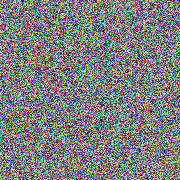

(180, 180) Image

In [17]:
c1 = LoadImage("c1.tiff"); c1

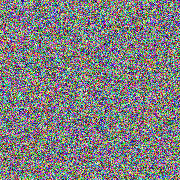

(180, 180) Image

In [18]:
c2 = LoadImage("c2.tiff"); c2

On peut supposer que la même clef a été utilisée pour ciffrer les deux messages.
L'application du masque consistant en un XOR, réappliquer le meme masque permet de le neutraliser : M XOR K XOR K = M

Par une addition des deux ciffrés, il est possible de "neutraliser" le masque et donc obtenir une image égale à la somme des deux images originales : C1 + C2 = M1 XOR K XOR M2 XOR K = M1 XOR M2 

On ne peut donc pas identifier chacun des messages initiaux mais se faire une idée sur leur contenu.

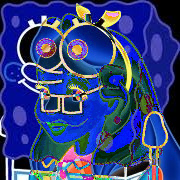

(180, 180) Image

In [ ]:
# c1 = m1 + k
# c2 = m2 + k
# c1 + c2 = m1 + m2 + (2k == 0)
m1m2 = c1 + c2
c1 + c2 # fusion des deux images


Ici on voit donc la "somme" des deux messages initiaux soit les portaits de Bob et d'Alice superposés.
Les messages initiaux auraient très bien pu être le portrait de Bob et le portrait d'Alice mais aussi une image "vide" ainsi que les portraits superposés.

## 4) Weak random number generator

After realizing my mistake, I decided to generate pads from a 128-bit key by using it as a seed for a linear congruence generator modulo the following 128-bit prime:

In [46]:
p = 340282366920938463463374607431768211507
p

340282366920938463463374607431768211507

Since such a PRNG is characterized by two 128-bit integers $a$ and $b$ which were chosen at random, there should be more than enough entropy to protect my 128-bit key, right? Here are the first few outputs from the LCG:

217692597915196650809181220736554072509,
101697276836279744146238049998237762682,
265181937610212296333751058245677871006,
84171444745593992579687306707926595136,
12455596861516498286468598807461112654,
...

prove me wrong by finding out which seed (<i>i.e.</i> "private key") was used.

NB: the 3-argument [`pow` function](https://docs.python.org/3/library/functions.html#pow) in Python may be useful to compute modular inverses.

Un LCG est basé sur une fonction affine de type x[n] = ( a * x[n-1] + b ) % p .
A partir de 3 sorties du générateur, si l'on connaît, il est possible d'identifier simplement les coefficients a et b.

```txt
x1 = a * x0 + b % p
x2 = a * x1 + b % p
x2-x1 = a(x1-x0) % p

a = ( (x2 - x1) * inv_mod_p(x1-x0) ) % p
b = (x1 - a * x0) % p 
``` 

En connaissant a, b et x[n] on peut retrouver x[n-1].
```txt
x1 = (a * x0 + b) % p
x0 = ( ( x1-b ) * inv_mod_p(a) ) % p
```
Quand n=0, x[n] = x[0] est la graine utilisée.

In [25]:
# x(n+1) = (ax(n) + b ) % p
p = 340282366920938463463374607431768211507
x1 = 217692597915196650809181220736554072509 # x1 = a * x0 + b % p
x2 = 101697276836279744146238049998237762682 # x2 = a * x1 + b % p
x3 = 265181937610212296333751058245677871006 # x3 = a * x2 + b % p
x4 = 84171444745593992579687306707926595136 # x4 = a * x3 + b % p
x5 = 12455596861516498286468598807461112654 # x5 = a * x4 + b % p

def inv_mod_p(n, p):
    return pow(n, -1, p)

def find_a_b(x0, x1, x2, p):
    # x1 = (ax0+b) % p
    # x2 = (ax1+b) % p
    # x2-x1 = a(x1-x0) % p
    # a = (x2-x1)/(x1-x0) % p
    a = ((x2-x1) * inv_mod_p(x1-x0, p)) % p
    # b = x1 - ax0
    b = (x1 - a * x0) % p
    return (a, b)

# Utilisons x1, x2, x3 pour trouver a et b
a, b = find_a_b(x1, x2, x3, p)

def find_x0(a, b, x1, p):
    # x1 = ax0 + b (mod p)
    # x0 = (x1-b)/a (mod p)
    return ((x1-b) * inv_mod_p(a, p)) % p

x0 = find_x0(a, b, x1, p)

print(f'a: {a}')
print(f'b: {b}') 
print(f'x0: {x0}')
print()

# Vérification complète
sequence = [x0, x1, x2, x3, x4, x5]

for i, x in enumerate(sequence[:-1]):
    calculated = (a * x + b) % p
    actual = sequence[i+1]
    print(f"Match x{1+i}: {actual == calculated}")


a: 29879779137056188643413695637347256028
b: 261355376501628057578013110734163562795
x0: 116262181799952103953797009259690012116

Match x1: True
Match x2: True
Match x3: True
Match x4: True
Match x5: True


## 5) Genuine stream cipher

Ok, now it's time to start doing things properly. We will use the ChaCha20 generator provided by the [`randomgen` library](https://pypi.org/project/randomgen/) to generate a key-stream from a 128-bit key. We first aquire 128 bits of fresh random data from the [entropy pool of the system](https://docs.python.org/3/library/os.html#os.urandom). 

In [28]:
from os import urandom

k = urandom(16)      # 16 bytes of entropy coming from the OS
print(k.hex())

b15182f4baaf9a11e7ec4f1172c2e361


In [29]:
from numpy import random
from randomgen import ChaCha  # you may need to pip install randomgen

prng = random.Generator(ChaCha(seed=int(k.hex(),16)))

`prng` is now an instance of the ChaCha20 PRNG initialized with seed $k$; you can use to generate successive pixel values as follows.

In [30]:
[ prng.integers(255) for i in range(10) ]

[np.int64(127),
 np.int64(6),
 np.int64(105),
 np.int64(38),
 np.int64(200),
 np.int64(223),
 np.int64(6),
 np.int64(82),
 np.int64(150),
 np.int64(146)]

Note that if you re-initialize the PRNG with the same seed $k$, you get exactly the same values in the same order.

In [31]:
prng = random.Generator(ChaCha(seed=int(k.hex(),16)))

[ prng.integers(255) for i in range(10) ]

[np.int64(127),
 np.int64(6),
 np.int64(105),
 np.int64(38),
 np.int64(200),
 np.int64(223),
 np.int64(6),
 np.int64(82),
 np.int64(150),
 np.int64(146)]

Use this to generate of pseudo-random pad from $k$, and then encrypt the Bletchley Park picture with it. Make sure that Bob is able to decrypt it knowing only $k$. 

In [73]:
def random_color( prng ):
    return [ prng.integers(255) for i in range(3) ]

def random_image(w,h, prng):
    colors = [ [random_color(prng) for _ in range(w)] for _ in range(h)]
    return Image( numpy.array(colors))
    

Message 

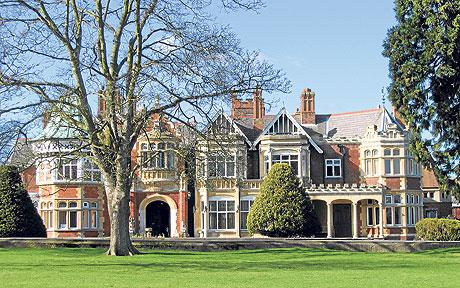

(288, 460) Image
Key: a26cff56f310fd5e1f6a16652a15c4f3
Cyphered: 

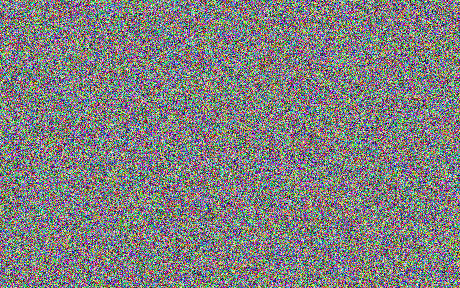

(288, 460) Image
Decyphered: 

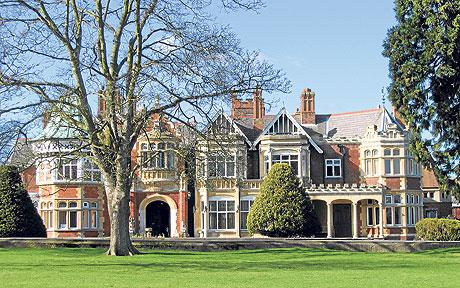

(288, 460) Image


In [ ]:
print("Bob cherche à envoyer le message suivant à Alice", m)
k = urandom(16)
print("Key:", k.hex())
print(f"Un générateur de nombres pseudo-aléatoires (PRNG) sera créé à partir de la clef suivante {k}, clef qui sera transmise à Alice par un autre canal.")

bob_prng = random.Generator(ChaCha(seed=int(k.hex(),16)))

h,w = m.size()
w,h
bob_mask = random_image(w,h, bob_prng)
print("Le masque à appliquer est généré par le PRNG :", bob_mask)

c = m + bob_mask
print("Bob envoie le message chiffré avec le masque à Alice.")

print("Eve intercepte le chiffré qu'elle ne peut pas déchiffrer en absence du masque ou de la clef:", c)

alice_prng = random.Generator(ChaCha(seed=int(k.hex(),16)))
alice_mask = random_image(w,h, alice_prng)
print("Alice de son côté a recréé le PRNG à partir de la clef fournie par Bob et régénéré le masque", alice_mask)
print("Le masque d'Alice est identique à celui de Bob ?:", alice_mask==bob_mask)

print("Alice déchiffre le chiffré et peut donc récupérer le message:", c + alice_mask)
